# OpenMesh Rain Event Detection

This notebook detects rain events using OpenMesh CML (Commercial Microwave Links) data and compares with ground truth measurements:

1. **OpenMesh CML** - Commercial Microwave Links (RSL and attenuation data)
2. **PWS** - Personal Weather Stations (rainfall measurements)
3. **NOAA ASOS** - Automated Surface Observing System (rainfall measurements)

**Focus:** Rain event **detection** (identifying when rain occurs: 1 = rain, 0 = no rain).

All data is loaded from the `dataset/` folder and analyzed on the same time axis.


## 0. Required Data Files

Before running this notebook, ensure you have the following data files in the correct locations:

### Required Directory Structure

```
OpenMesh/
├── dataset/
│   ├── links/
│   │   ├── ds_openmesh.nc          # ⚠ REQUIRED: OpenMesh CML NetCDF file
│   │   └── links_metadata.csv      # ⚠ REQUIRED: Link metadata
│   └── weather stations/
│       ├── pws_opensense_os.nc     # ⚠ REQUIRED: PWS NetCDF file (or pws_opensense_sample_jan.nc)
│       └── pws_metadata.csv        # Optional: PWS station metadata
└── src/
    └── data/
        └── noaa_asos/
            └── *.csv                # ⚠ REQUIRED: ASOS CSV files (e.g., ALL_STATIONS_*.csv)
```

### How to Obtain the Data Files

#### 1. OpenMesh CML Data (`ds_openmesh.nc`)

**Option A: Download from Zenodo (Recommended)**
- **URL:** https://zenodo.org/records/15287692
- **File:** `OpenMesh.zip` (≈330 MB)
- **Extract to:** `dataset/links/`
- **Required files:**
  - `ds_openmesh.nc` - Main NetCDF file with RSL time-series
  - `links_metadata.csv` - Link coordinates, frequency, polarization

**Option B: Use Download Notebook**
- Run: `src/fetch_data/openmesh/download_and_read_openmesh.ipynb`
- This will automatically download and extract the files

#### 2. PWS Data (`pws_opensense_os.nc` or `pws_opensense_sample_jan.nc`)

**Option A: From Zenodo Archive (Recommended)**

The code automatically searches in two locations:

1. **Extracted and moved (Recommended):**
   - Extract `OpenMesh.zip` from Zenodo
   - Copy/move files to: `dataset/weather stations/`
   - Files needed:
     - `pws_opensense_sample_jan.nc` - Sample (2 weeks: Jan 15-30, 2024)
     - `pws_opensense_os.nc` - Full dataset (Oct 2023 - Jul 2024)

2. **Use extracted path directly:**
   - If you extracted `OpenMesh.zip` to `src/data/openmesh/extracted/`
   - Files are already at: `src/data/openmesh/extracted/dataset/weather stations/`
   - The code will automatically find them there

**Note:** 
- **Sample file** (`pws_opensense_sample_jan.nc`): 2-week demo data (Jan 15-30, 2024)
- **Full file** (`pws_opensense_os.nc`): Complete dataset (Oct 2023 - Jul 2024)
- Both files are included in the Zenodo archive

**Option B: Fetch via API**
- Use: `src/fetch_data/weather_underground/wu_pipeline.ipynb`
- Fetches data from Weather Underground API
- Outputs to: `src/data/wu_pws/` (convert to NetCDF format if needed)

#### 3. NOAA ASOS Data (`*.csv` files)

**Option A: Fetch via 1-Minute Pipeline (Recommended)**
- Use: `src/fetch_data/noaa_asos/asos_pipeline.ipynb`
- Fetches TRUE per-minute precipitation data (not hourly running totals)
- Configure stations and date range in the notebook
- Outputs CSV files to: `src/data/noaa_asos/`
- **Example stations:** `['JFK', 'LGA', 'NYC']` for NYC area (1-minute pipeline)
- **Note:** Data can be resampled to any interval (5min, 10min, 1H, etc.) in the pipeline

**Option B: Manual Download**
- Visit: https://mesonet.agron.iastate.edu/request/download.phtml
- Download CSV files for desired stations and dates
- Place in: `src/data/noaa_asos/` or `dataset/weather stations/`

### File Search Locations

The notebook will automatically search for files in these locations (in order):

**CML Data:**
- `dataset/links/ds_openmesh.nc`
- `src/data/openmesh/extracted/dataset/links/ds_openmesh.nc`

**PWS Data (searched in order):**
- `dataset/weather stations/pws_opensense_os.nc` (full dataset)
- `dataset/weather stations/pws_opensense_sample_jan.nc` (sample)
- `src/data/openmesh/extracted/dataset/weather stations/pws_opensense_os.nc` (extracted)
- `src/data/openmesh/extracted/dataset/weather stations/pws_opensense_sample_jan.nc` (extracted)

**Note:** You can either:
- Extract and move files to `dataset/weather stations/` (recommended)
- OR use files directly from `src/data/openmesh/extracted/dataset/weather stations/` (if extracted there)

**ASOS Data:**
- `src/data/noaa_asos/*.csv`
- `dataset/weather stations/*.csv`

### Verification

After placing files, run the data loading cells (Section 2) to verify all files are found. The notebook will print:
- ✓ Found messages for each file
- ✗ Error messages if files are missing

**Note:** If you see "✗ File not found" errors, check:
1. File names match exactly (case-sensitive)
2. Files are in one of the search directories listed above
3. File permissions allow reading


In [1]:
# Restart Kernel - Clear all variables
# Run this cell if you need a fresh start
%reset -f
print("✓ Kernel reset - all variables cleared")


✓ Kernel reset - all variables cleared


## 1. Setup and Imports


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator
from pathlib import Path

# Import helper functions
from load_data import (
    load_openmesh_cml,
    load_pws_data,
    load_noaa_asos,
    extract_cml_timeseries,
    extract_pws_rainfall,
    extract_all_pws_rainfall
)
from plotting import plot_cml_rsl_attenuation, plot_all_datasets, plot_rain_detection, plot_both_detection_methods
from load_data import detect_rain_constant_threshold

print("✓ Imports successful")


✓ Imports successful


## 2. Load All Datasets

This section demonstrates how to load data from different sources:
- OpenMesh CML NetCDF files
- PWS NetCDF files  
- NOAA ASOS CSV files


In [3]:
# Load OpenMesh CML data
print("=" * 70)
print("LOADING OPENMESH CML DATA")
print("=" * 70)
ds_cml, df_metadata = load_openmesh_cml()
print()


LOADING OPENMESH CML DATA
Loading OpenMesh CML data from: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/links/ds_openmesh.nc
  ✓ Loaded CML dataset:
    Links: 75
    Time range: 2023-10-29 00:00:00 to 2024-07-01 00:00:00
    Time points: 354,241
  ✓ Loaded metadata: 103 sublinks



In [4]:
# Load PWS data - Choose your source:
# Options:
#   - 'full': Load from full NetCDF file (all periods, extracted dataset)
#   - 'sample': Load sample NetCDF data from dataset folder

PWS_SOURCE = 'sample'  # Change to 'sample' for sample data

print("=" * 70)
print("LOADING PWS DATA")
print(f"Source: {PWS_SOURCE.upper()} NetCDF")
print("=" * 70)

if PWS_SOURCE == 'sample':
    pws_data = load_pws_data(source='sample')
else:  # 'full' or default
    pws_data = load_pws_data(source='full')

print()


LOADING PWS DATA
Source: SAMPLE NetCDF
Loading SAMPLE PWS data from NetCDF: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/weather stations/pws_opensense_sample_jan.nc
Loading FULL PWS data from NetCDF: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/weather stations/pws_opensense_sample_jan.nc
  Found 37 stations
    ✓ KNYNEWYO1472: 4402 records
    ✓ KNYNEWYO1659: 4606 records
    ✓ KNYNEWYO1288: 3743 records
    ✓ KNYNEWYO1896: 4606 records
    ✓ KNYNEWYO1921: 4605 records
    ✓ KNYNEWYO1931: 4606 records
    ✓ KNYNEWYO1313: 4604 records
    ✓ KNYNEWYO1918: 4604 records
    ✓ KNYNEWYO1298: 4606 records
    ✓ KNYNEWYO1388: 4599 records
    ✓ KNYNEWYO1606: 4606 records
    ✓ KNYNEWYO1943: 290 records
    ✓ KNYNEWYO1348: 4606 records
    ✓ KNYNEWYO1942: 373 records
    ✓ KNYNEWYO1238: 4544 records
    ✓ KNYNEWYO1401: 4587 records
    ✓ KNYNEWYO1824: 4605 records
    ✓ KNYNEWYO343: 4606 records
    ✓ KNYNEWYO1626: 4604 records
    ✓ KNYNEWYO1747: 1171 records
    ✓ KNYNEWYO

In [5]:
# Debug: Check what data was actually loaded
print("=" * 70)
print("DEBUG: CHECKING LOADED DATA")
print("=" * 70)

if 'pws_data' in locals():
    print(f"✓ PWS data loaded: {len(pws_data)} stations")
else:
    print("✗ PWS data not loaded")

if 'df_pws' in locals() and df_pws is not None:
    print(f"✓ PWS DataFrame:")
    print(f"  Time range: {df_pws.index.min()} to {df_pws.index.max()}")
    print(f"  Records: {len(df_pws):,}")
    print(f"  Stations: {len(df_pws.columns)}")
else:
    print("✗ PWS DataFrame not available")

if 'df_asos' in locals() and df_asos is not None:
    print(f"\n✓ ASOS DataFrame:")
    print(f"  Time range: {df_asos.index.min()} to {df_asos.index.max()}")
    print(f"  Records: {len(df_asos):,}")
    if len(df_asos.columns) > 0:
        print(f"  Stations: {list(df_asos.columns)}")
else:
    print("\n✗ ASOS DataFrame not available or empty")
    print("  → Check if ASOS file exists and covers Jan 15-30, 2024")
    print("  → Run: src/fetch_data/noaa_asos/asos_pipeline.ipynb to fetch 1-minute ASOS data")

print("=" * 70)


DEBUG: CHECKING LOADED DATA
✓ PWS data loaded: 37 stations
✗ PWS DataFrame not available

✗ ASOS DataFrame not available or empty
  → Check if ASOS file exists and covers Jan 15-30, 2024
  → Run: src/fetch_data/noaa_asos/asos_pipeline.ipynb to fetch 1-minute ASOS data


In [6]:
# Load NOAA ASOS data (if available)
# Automatically find and load ASOS files from src/data/noaa_asos/
print("=" * 70)
print("LOADING NOAA ASOS DATA")
print("=" * 70)

from pathlib import Path
import pandas as pd

# Search for ASOS CSV files
# Try multiple possible paths (notebook may run from different locations)
asos_dir = None
possible_paths = [
    Path("../data/noaa_asos"),  # From src/analysis/
    Path("../../data/noaa_asos"),  # From project root
    Path("src/data/noaa_asos"),  # From project root
    Path(__file__).parent.parent / "data" / "noaa_asos" if '__file__' in globals() else None,  # Absolute
]

for p in possible_paths:
    if p and p.exists():
        asos_dir = p
        break

# Fallback: try to find from project root
if asos_dir is None:
    import os
    project_root = Path(os.getcwd())
    # Go up until we find src/data/noaa_asos
    for parent in [project_root] + list(project_root.parents):
        test_path = parent / "src" / "data" / "noaa_asos"
        if test_path.exists():
            asos_dir = test_path
            break

csv_files = list(asos_dir.glob("*.csv")) if asos_dir and asos_dir.exists() else []

if asos_dir is None or len(csv_files) == 0:
    if asos_dir is None:
        print("✗ ASOS directory not found")
        print("  → Searched in: ../data/noaa_asos, ../../data/noaa_asos, src/data/noaa_asos")
    else:
        print(f"✗ No ASOS CSV files found in {asos_dir}")
    print("  → To fetch ASOS data, run: src/fetch_data/noaa_asos/asos_pipeline.ipynb")
    print("  → Expected location: src/data/noaa_asos/")
    df_asos = None
elif len(csv_files) == 1:
    # Only one file - use it automatically
    csv_file = csv_files[0]
    print(f"✓ Found ASOS file: {csv_file.name}")
    print(f"  Loading from: {csv_file}")
    
    try:
        df_asos = pd.read_csv(csv_file)
        
        # Convert datetime column if present
        if 'datetime' in df_asos.columns:
            df_asos['datetime'] = pd.to_datetime(df_asos['datetime'])
            df_asos.set_index('datetime', inplace=True)
        elif 'time' in df_asos.columns:
            df_asos['time'] = pd.to_datetime(df_asos['time'])
            df_asos.set_index('time', inplace=True)
        else:
            print("  ⚠ Warning: No 'datetime' or 'time' column found")
            df_asos = None
        
        if df_asos is not None:
            # If multiple stations, pivot to have one column per station
            if 'station_id' in df_asos.columns and 'precip_mm' in df_asos.columns:
                # Pivot: station_id as columns, precip_mm as values
                df_asos = df_asos.pivot_table(
                    values='precip_mm', 
                    index=df_asos.index, 
                    columns='station_id'
                )
            elif 'precip_mm' in df_asos.columns:
                # Single station format - keep as is
                pass
            else:
                # Try to find precipitation column
                precip_cols = [c for c in df_asos.columns if 'precip' in c.lower()]
                if precip_cols:
                    print(f"  ✓ Using precipitation column: {precip_cols[0]}")
                else:
                    print("  ⚠ Warning: No precipitation column found")
                    df_asos = None
            
            if df_asos is not None:
                print(f"  ✓ Loaded: {len(df_asos):,} records")
                print(f"  ✓ Time range: {df_asos.index.min()} to {df_asos.index.max()}")
                if len(df_asos.columns) > 0:
                    print(f"  ✓ Stations/columns: {list(df_asos.columns)}")
    except Exception as e:
        print(f"  ✗ Error loading file: {e}")
        df_asos = None
else:
    # Multiple files - use the most recent or largest
    print(f"ℹ Found {len(csv_files)} ASOS files:")
    for f in csv_files:
        print(f"  - {f.name}")
    
    # Prefer ALL_STATIONS files, then most recent
    all_stations_files = [f for f in csv_files if 'ALL_STATIONS' in f.name.upper()]
    if all_stations_files:
        csv_file = sorted(all_stations_files, key=lambda x: x.stat().st_mtime, reverse=True)[0]
    else:
        csv_file = sorted(csv_files, key=lambda x: x.stat().st_mtime, reverse=True)[0]
    
    print(f"\n✓ Using: {csv_file.name}")
    print(f"  Loading from: {csv_file}")
    
    try:
        df_asos = pd.read_csv(csv_file)
        
        # Convert datetime column if present
        if 'datetime' in df_asos.columns:
            df_asos['datetime'] = pd.to_datetime(df_asos['datetime'])
            df_asos.set_index('datetime', inplace=True)
        elif 'time' in df_asos.columns:
            df_asos['time'] = pd.to_datetime(df_asos['time'])
            df_asos.set_index('time', inplace=True)
        else:
            print("  ⚠ Warning: No 'datetime' or 'time' column found")
            df_asos = None
        
        if df_asos is not None:
            # If multiple stations, pivot to have one column per station
            if 'station_id' in df_asos.columns and 'precip_mm' in df_asos.columns:
                df_asos = df_asos.pivot_table(
                    values='precip_mm', 
                    index=df_asos.index, 
                    columns='station_id'
                )
            
            if df_asos is not None:
                print(f"  ✓ Loaded: {len(df_asos):,} records")
                print(f"  ✓ Time range: {df_asos.index.min()} to {df_asos.index.max()}")
                if len(df_asos.columns) > 0:
                    print(f"  ✓ Stations/columns: {list(df_asos.columns)}")
    except Exception as e:
        print(f"  ✗ Error loading file: {e}")
        df_asos = None

print()


LOADING NOAA ASOS DATA
✓ Found ASOS file: ALL_STATIONS_1min.csv
  Loading from: ../data/noaa_asos/ALL_STATIONS_1min.csv
  ✓ Loaded: 41,225 records
  ✓ Time range: 2024-01-01 00:00:00 to 2024-01-29 23:59:00
  ✓ Stations/columns: ['JFK', 'LGA', 'NYC']



## 3. Extract Time Series

This section shows how to extract and process time series data from the loaded datasets:
- CML RSL and attenuation calculation
- PWS rainfall extraction
- ASOS precipitation extraction


In [7]:
# Extract CML time series for a specific link
selected_link_id = '1'
selected_sublink = 'sublink_1'

df_cml = extract_cml_timeseries(ds_cml, link_id=selected_link_id, sublink_id=selected_sublink)

print(f"✓ Extracted CML data for Link {selected_link_id}, {selected_sublink}")
print(f"  Time points: {len(df_cml):,}")
print(f"  Time range: {df_cml.index.min()} to {df_cml.index.max()}")
print(f"  RSL range: {df_cml['rsl'].min():.2f} to {df_cml['rsl'].max():.2f} dBm")
print(f"  Max attenuation: {df_cml['attenuation'].max():.2f} dB")


✓ Extracted CML data for Link 1, sublink_1
  Time points: 354,241
  Time range: 2023-10-29 00:00:00 to 2024-07-01 00:00:00
  RSL range: -79.00 to -47.00 dBm
  Max attenuation: 27.00 dB


/Users/drorjac/PycharmProjects/OpenMesh-fresh/src/analysis/load_data.py:836: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rolling_baseline = df_cml['rsl'].rolling(window=window_size, min_periods=1).quantile(0.95)


In [8]:
# Extract PWS rainfall data from ALL stations
# data is associated with netCDF pws file
df_pws = extract_all_pws_rainfall(pws_data)


print(f"\n✓ Extracted PWS rainfall data from all stations")
print(f"  Stations: {len(df_pws.columns)}")
print(f"  Time points: {len(df_pws):,}")
print(f"  Time range: {df_pws.index.min()} to {df_pws.index.max()}")
print(f"  Columns (stations): {list(df_pws.columns)[:5]}..." if len(df_pws.columns) > 5 else f"  Columns (stations): {list(df_pws.columns)}")




Extracting rainfall from 37 PWS stations...
  ✓ KNYNEWYO1472: 4,402 records
  ✓ KNYNEWYO1659: 4,606 records
  ✓ KNYNEWYO1288: 3,743 records
  ✓ KNYNEWYO1896: 4,606 records
  ✓ KNYNEWYO1921: 4,605 records
  ✓ KNYNEWYO1931: 4,606 records
  ✓ KNYNEWYO1313: 4,604 records
  ✓ KNYNEWYO1918: 4,604 records
  ✓ KNYNEWYO1298: 4,606 records
  ✓ KNYNEWYO1388: 4,599 records
  ✓ KNYNEWYO1606: 4,606 records
  ✓ KNYNEWYO1943: 290 records
  ✓ KNYNEWYO1348: 4,606 records
  ✓ KNYNEWYO1942: 373 records
  ✓ KNYNEWYO1238: 4,544 records
  ✓ KNYNEWYO1401: 4,587 records
  ✓ KNYNEWYO1824: 4,605 records
  ✓ KNYNEWYO343: 4,606 records
  ✓ KNYNEWYO1626: 4,604 records
  ✓ KNYNEWYO1747: 1,171 records
  ✓ KNYNEWYO589: 4,605 records
  ✓ KNYNEWYO1591: 4,606 records
  ✓ KNYNEWYO638: 3,958 records
  ✓ KNYNEWYO1796: 4,606 records
  ✓ KNYNEWYO1805: 4,534 records
  ✓ KNYNEWYO1622: 4,606 records
  ✓ KNYNEWYO1024: 1,506 records
  ✓ KNYNEWYO1533: 4,580 records
  ✓ KNYNEWYO1651: 1,534 records
  ✓ KNYNEWYO1120: 4,606 records
  ✓

## 4. Time Range Summary

All three data sources have been extracted and processed. Below is a summary of their time ranges.


In [9]:
# Display time range summary for all three data sources
print("=" * 70)
print("TIME RANGE SUMMARY")
print("=" * 70)

time_ranges = {}

if df_cml is not None and len(df_cml) > 0:
    time_ranges['CML'] = (df_cml.index.min(), df_cml.index.max())
    print(f"\n✓ CML Data:")
    print(f"  Time range: {df_cml.index.min()} to {df_cml.index.max()}")
    print(f"  Records: {len(df_cml):,}")

if df_pws is not None and len(df_pws) > 0:
    time_ranges['PWS'] = (df_pws.index.min(), df_pws.index.max())
    print(f"\n✓ PWS Data:")
    print(f"  Time range: {df_pws.index.min()} to {df_pws.index.max()}")
    print(f"  Records: {len(df_pws):,}")
    print(f"  Stations: {len(df_pws.columns)}")

if df_asos is not None and len(df_asos) > 0:
    time_ranges['ASOS'] = (df_asos.index.min(), df_asos.index.max())
    print(f"\n✓ ASOS Data:")
    print(f"  Time range: {df_asos.index.min()} to {df_asos.index.max()}")
    print(f"  Records: {len(df_asos):,}")
    if len(df_asos.columns) > 0:
        print(f"  Stations: {len(df_asos.columns)}")

print("\n" + "=" * 70)


TIME RANGE SUMMARY

✓ CML Data:
  Time range: 2023-10-29 00:00:00 to 2024-07-01 00:00:00
  Records: 354,241

✓ PWS Data:
  Time range: 2024-01-15 00:00:00 to 2024-01-30 23:59:00
  Records: 13,134
  Stations: 37

✓ ASOS Data:
  Time range: 2024-01-01 00:00:00 to 2024-01-29 23:59:00
  Records: 41,225
  Stations: 3



In [10]:
## 5. Optional: Filter by Date Range or Use Intersection

#Choose one of the following options:
#1. **Manual date selection** - Set custom start/end dates
#2. **Automatic intersection** - Use the overlapping period where all three datasets exist



### Option 1: Manual Date Selection

Set custom start and end dates to filter all datasets:


In [11]:
# OPTION 1: Manual date selection
# Uncomment and set your desired dates:
# start_date = pd.Timestamp('2024-01-01')
# end_date = pd.Times tamp('2024-01-14 23:59:59')

# OPTION 2: Automatic intersection (default - finds overlapping period)
# Leave start_date and end_date as None to use intersection
start_date = None  # Set to None for automatic intersection
end_date = None     # Set to None for automatic intersection

# Find intersection of all available datasets
available_datasets = []
if df_cml is not None and len(df_cml) > 0:
    available_datasets.append(('CML', df_cml.index.min(), df_cml.index.max()))
if df_pws is not None and len(df_pws) > 0:
    available_datasets.append(('PWS', df_pws.index.min(), df_pws.index.max()))
if df_asos is not None and len(df_asos) > 0:
    available_datasets.append(('ASOS', df_asos.index.min(), df_asos.index.max()))

if len(available_datasets) == 0:
    print("⚠ No datasets available for filtering")
    df_cml_filtered = None
    df_pws_filtered = None
    df_asos_filtered = None
else:
    # If dates not provided, use intersection
    if start_date is None or end_date is None:
        # Find intersection: latest start and earliest end
        time_starts = [ds[1] for ds in available_datasets]
        time_ends = [ds[2] for ds in available_datasets]
        intersection_start = max(time_starts)  # Latest start = intersection start
        intersection_end = min(time_ends)      # Earliest end = intersection end
        
        if start_date is None:
            start_date = intersection_start
        if end_date is None:
            end_date = intersection_end
        
        print("=" * 70)
        print("AUTOMATIC INTERSECTION MODE")
        print("=" * 70)
        print(f"\n📅 Found intersection of all {len(available_datasets)} datasets:")
        for name, ds_start, ds_end in available_datasets:
            print(f"  {name}: {ds_start} to {ds_end}")
        print(f"\n✓ Using shared period: {start_date} to {end_date}")
    else:
        print("=" * 70)
        print("MANUAL DATE SELECTION MODE")
        print("=" * 70)
        print(f"\n✓ Using custom date range: {start_date} to {end_date}")
    
    # Filter all three datasets to the selected date range
    print("\n" + "-" * 70)
    print("Filtering datasets...")
    print("-" * 70)
    
    # Filter CML
    if df_cml is not None and len(df_cml) > 0:
        df_cml_filtered = df_cml[(df_cml.index >= start_date) & (df_cml.index <= end_date)].copy()
        print(f"✓ CML: {len(df_cml_filtered):,} records in date range")
    else:
        df_cml_filtered = None
        print("✗ CML: No data available")
    
    # Filter PWS
    if df_pws is not None and len(df_pws) > 0:
        df_pws_filtered = df_pws[(df_pws.index >= start_date) & (df_pws.index <= end_date)].copy()
        print(f"✓ PWS: {len(df_pws_filtered):,} records in date range ({len(df_pws_filtered.columns)} stations)")
    else:
        df_pws_filtered = None
        print("✗ PWS: No data available")
    
    # Filter ASOS
    if df_asos is not None and len(df_asos) > 0:
        df_asos_filtered = df_asos[(df_asos.index >= start_date) & (df_asos.index <= end_date)].copy()
        print(f"✓ ASOS: {len(df_asos_filtered):,} records in date range")
        if len(df_asos_filtered.columns) > 0:
            print(f"    Stations: {len(df_asos_filtered.columns)}")
    else:
        df_asos_filtered = None
        print("✗ ASOS: No data available")
    
    print("\n" + "=" * 70)
    print("✓ All datasets filtered to shared time period")
    print("=" * 70)


AUTOMATIC INTERSECTION MODE

📅 Found intersection of all 3 datasets:
  CML: 2023-10-29 00:00:00 to 2024-07-01 00:00:00
  PWS: 2024-01-15 00:00:00 to 2024-01-30 23:59:00
  ASOS: 2024-01-01 00:00:00 to 2024-01-29 23:59:00

✓ Using shared period: 2024-01-15 00:00:00 to 2024-01-29 23:59:00

----------------------------------------------------------------------
Filtering datasets...
----------------------------------------------------------------------
✓ CML: 21,600 records in date range
✓ PWS: 12,355 records in date range (37 stations)
✓ ASOS: 21,065 records in date range
    Stations: 3

✓ All datasets filtered to shared time period


## 6. Visualize All Datasets

This section demonstrates how to plot and visualize all three datasets (CML, PWS, ASOS) on the same time axis for comparison.


## 4. Filter High Values and Outliers

Filter out unrealistic precipitation values.


In [12]:
import numpy as np
import pandas as pd

# ============================================================================
# CONFIGURATION - CONSERVATIVE APPROACH
# ============================================================================
# Physical limits (very permissive - only remove truly impossible values)
MAX_PHYSICAL_LIMIT = 10.0     # mm/5min (extremely heavy rain, ~120mm/hr)
MIN_PHYSICAL_LIMIT = 0.0      # No negative precipitation

# Optional: Remove only extreme spikes (disabled by default)
USE_SPIKE_DETECTION = False   # Detect sudden jumps
SPIKE_THRESHOLD = 5.0         # Only flag if change > 5mm in one timestep

# ============================================================================
# METHOD 1: PHYSICAL LIMITS ONLY (MOST CONSERVATIVE)
# ============================================================================
def clean_physical_limits_only(df, dataset_name, max_limit=10.0):
    """
    Only remove physically impossible values.
    Most conservative - removes <0.1% of data typically.
    """
    if df is None or len(df) == 0:
        print(f"\n⚠ {dataset_name}: No data available")
        return None, {}
    
    df_clean = df.copy()
    
    # Get numeric columns
    if 'precip_mm' in df_clean.columns:
        cols = ['precip_mm']
    else:
        cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"\n{dataset_name}: {len(df_clean):,} records, {len(cols)} column(s)")
    
    # Track stats
    initial_max = df_clean[cols].max().max()
    total_removed = 0
    
    for col in cols:
        # Remove negative values
        neg_mask = df_clean[col] < 0
        n_neg = neg_mask.sum()
        
        # Remove extremely high values
        extreme_mask = df_clean[col] > max_limit
        n_extreme = extreme_mask.sum()
        
        # Apply filters
        df_clean.loc[neg_mask | extreme_mask, col] = np.nan
        total_removed += (n_neg + n_extreme)
        
        if n_neg > 0:
            print(f"  ⚠ Removed {n_neg} negative values from {col}")
        if n_extreme > 0:
            print(f"  ⚠ Removed {n_extreme} extreme values (>{max_limit}mm) from {col}")
    
    final_max = df_clean[cols].max().max()
    
    print(f"  Initial max: {initial_max:.4f} mm → Final max: {final_max:.4f} mm")
    print(f"  Total removed: {total_removed:,} ({100*total_removed/len(df_clean):.3f}%)")
    
    return df_clean, {'removed': total_removed, 'initial_max': initial_max, 'final_max': final_max}

# ============================================================================
# METHOD 2: PERCENTILE-BASED (MODERATE)
# ============================================================================
def clean_percentile_based(df, dataset_name, percentile=99.9):
    """
    Remove only top X percentile as outliers.
    Moderate approach - keeps 99.9% of data.
    """
    if df is None or len(df) == 0:
        print(f"\n⚠ {dataset_name}: No data available")
        return None, {}
    
    df_clean = df.copy()
    
    if 'precip_mm' in df_clean.columns:
        cols = ['precip_mm']
    else:
        cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"\n{dataset_name}: {len(df_clean):,} records, {len(cols)} column(s)")
    
    initial_max = df_clean[cols].max().max()
    total_removed = 0
    
    for col in cols:
        # Calculate threshold from non-zero values only
        non_zero = df_clean[col][(df_clean[col] > 0) & df_clean[col].notna()]
        
        if len(non_zero) > 100:
            threshold = non_zero.quantile(percentile / 100)
            
            # Remove values above threshold
            outlier_mask = df_clean[col] > threshold
            n_outliers = outlier_mask.sum()
            
            if n_outliers > 0:
                df_clean.loc[outlier_mask, col] = np.nan
                total_removed += n_outliers
                print(f"  {col}: Removed {n_outliers} values above {threshold:.2f}mm (>{percentile}th percentile)")
    
    final_max = df_clean[cols].max().max()
    
    print(f"  Initial max: {initial_max:.4f} mm → Final max: {final_max:.4f} mm")
    print(f"  Total removed: {total_removed:,} ({100*total_removed/len(df_clean):.3f}%)")
    
    return df_clean, {'removed': total_removed, 'threshold': threshold if 'threshold' in locals() else None}

# ============================================================================
# METHOD 3: ROLLING WINDOW SPIKE DETECTION (TARGETED)
# ============================================================================
def clean_spike_detection(df, dataset_name, spike_threshold=5.0, window=3):
    """
    Only remove sudden unrealistic spikes.
    Very targeted - only catches sensor errors/glitches.
    """
    if df is None or len(df) == 0:
        print(f"\n⚠ {dataset_name}: No data available")
        return None, {}
    
    df_clean = df.copy()
    
    if 'precip_mm' in df_clean.columns:
        cols = ['precip_mm']
    else:
        cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"\n{dataset_name}: {len(df_clean):,} records, {len(cols)} column(s)")
    
    total_removed = 0
    
    for col in cols:
        # Calculate rolling median
        rolling_median = df_clean[col].rolling(window=window, center=True).median()
        
        # Find points that deviate too much from neighbors
        deviation = (df_clean[col] - rolling_median).abs()
        spike_mask = deviation > spike_threshold
        
        n_spikes = spike_mask.sum()
        
        if n_spikes > 0:
            df_clean.loc[spike_mask, col] = np.nan
            total_removed += n_spikes
            print(f"  {col}: Removed {n_spikes} spike values (deviation >{spike_threshold}mm)")
    
    print(f"  Total removed: {total_removed:,} ({100*total_removed/len(df_clean):.3f}%)")
    
    return df_clean, {'removed': total_removed}

# ============================================================================
# CHOOSE YOUR METHOD
# ============================================================================
print("=" * 70)
print("PRECIPITATION DATA CLEANING - CONSERVATIVE METHODS")
print("=" * 70)

# OPTION 1: Physical limits only (RECOMMENDED - MOST CONSERVATIVE)
print("\n🔹 METHOD 1: Physical Limits Only (removes only impossible values)")
df_pws_filtered, pws_stats = clean_physical_limits_only(df_pws_filtered, 'PWS', max_limit=10.0)
df_asos_filtered, asos_stats = clean_physical_limits_only(df_asos_filtered, 'ASOS', max_limit=10.0)

# OPTION 2: Percentile-based (uncomment to use instead)
# print("\n🔹 METHOD 2: Percentile-Based (keeps 99.9% of data)")
# df_pws_filtered, pws_stats = clean_percentile_based(df_pws_filtered, 'PWS', percentile=99.9)
# df_asos_filtered, asos_stats = clean_percentile_based(df_asos_filtered, 'ASOS', percentile=99.9)

# OPTION 3: Spike detection (uncomment to use instead)
# print("\n🔹 METHOD 3: Spike Detection (removes only sudden jumps)")
# df_pws_filtered, pws_stats = clean_spike_detection(df_pws_filtered, 'PWS', spike_threshold=5.0)
# df_asos_filtered, asos_stats = clean_spike_detection(df_asos_filtered, 'ASOS', spike_threshold=5.0)

print("\n" + "=" * 70)
print("✓ CLEANING COMPLETE")
print("=" * 70)

PRECIPITATION DATA CLEANING - CONSERVATIVE METHODS

🔹 METHOD 1: Physical Limits Only (removes only impossible values)

PWS: 12,355 records, 37 column(s)
  ⚠ Removed 1 extreme values (>10.0mm) from KNYNEWYO1943
  ⚠ Removed 1 extreme values (>10.0mm) from KNYNEWYO1942
  ⚠ Removed 3 extreme values (>10.0mm) from KNYNEWYO1805
  Initial max: 20.0000 mm → Final max: 5.3340 mm
  Total removed: 5 (0.040%)

ASOS: 21,065 records, 3 column(s)
  ⚠ Removed 1 extreme values (>10.0mm) from LGA
  Initial max: 12.7000 mm → Final max: 0.2540 mm
  Total removed: 1 (0.005%)

✓ CLEANING COMPLETE


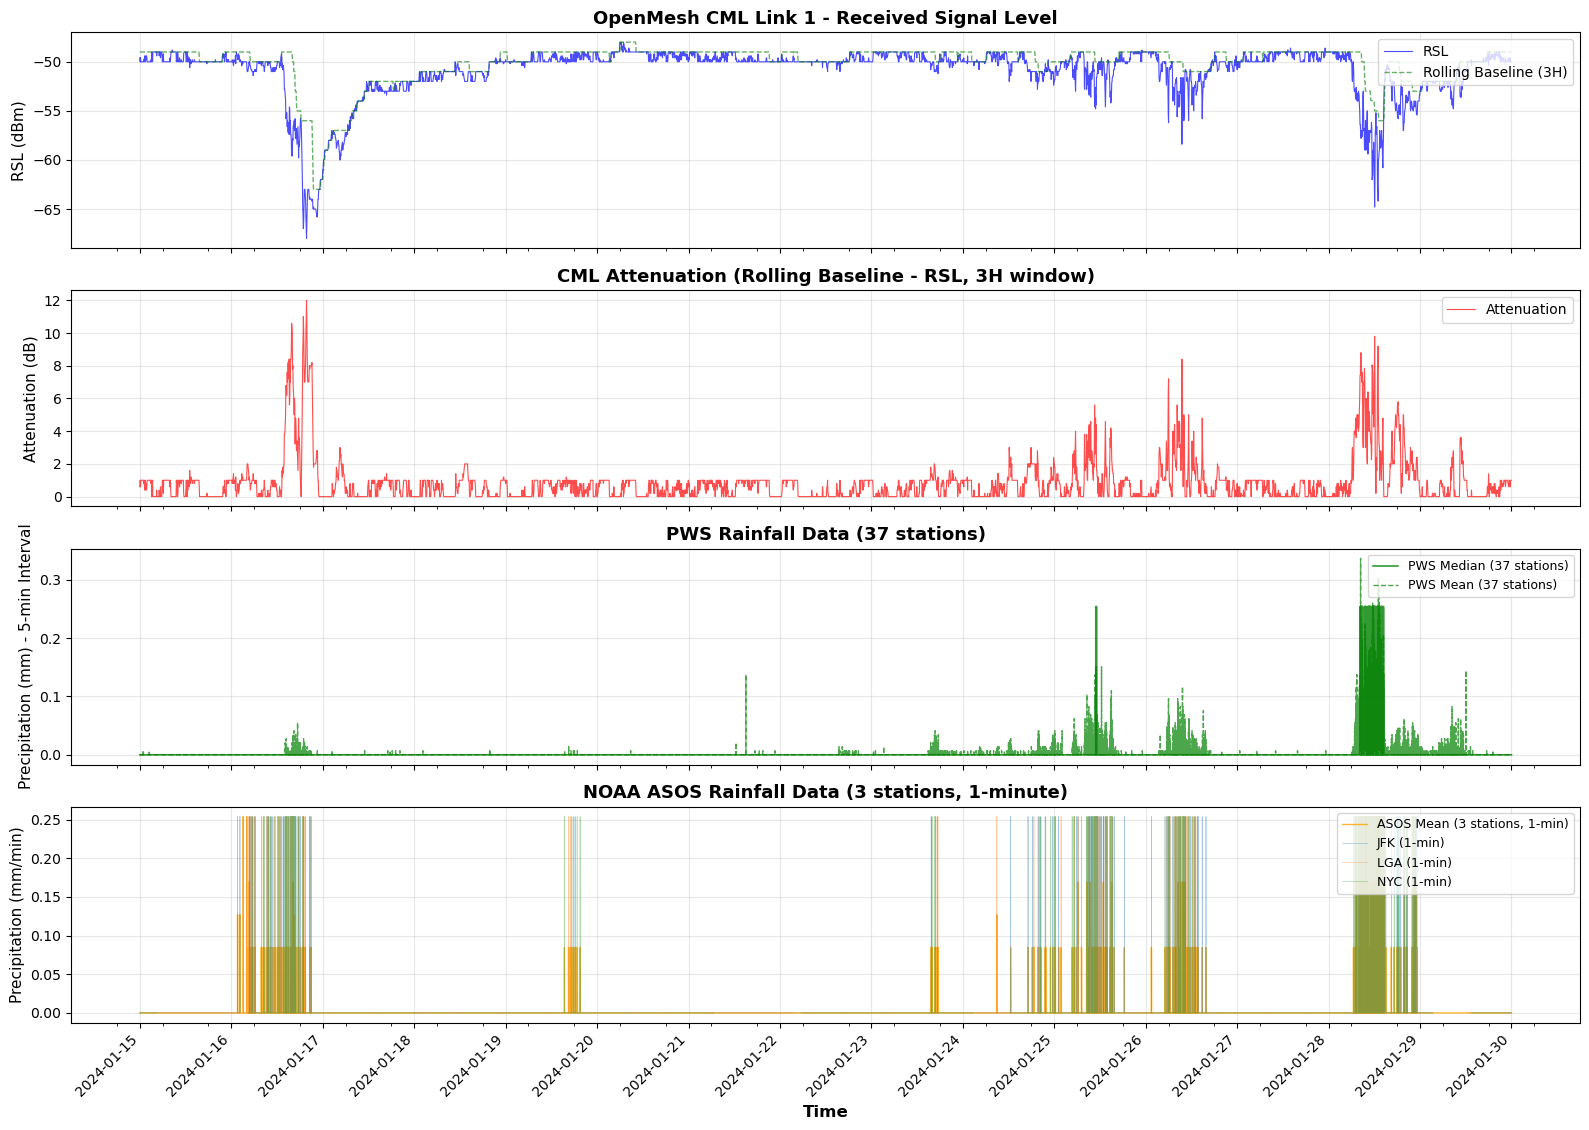

✓ Plotted all three datasets (CML, PWS, ASOS)


In [13]:
# Plot all three filtered datasets on the same time axis
# Uses the filtered datasets from the previous cell (df_cml_filtered, df_pws_filtered, df_asos_filtered)

plot_all_datasets(
    df_cml=df_cml_filtered,
    df_pws=df_pws_filtered,
    df_asos=df_asos_filtered,
    selected_link_id=selected_link_id,
    start_date=start_date,
    end_date=end_date 
)


## 7. Rain Event Detection

This section implements two methods for rain event detection from CML attenuation data:

1. **Constant Baseline Method** - Use a constant threshold (in dB) to detect rain events
2. **Rolling Std Method** - Use rolling statistics (mean + N×std) to detect rain events


### Setup: Prepare Data for Detection Analysis

This section aligns the filtered datasets on a common time index for the detection methods demonstrated below.


In [14]:
# Prepare aligned datasets for detection analysis
# Use the filtered datasets from Section 5

print("=" * 70)
print("PREPARING DATA FOR DETECTION ANALYSIS")
print("=" * 70)

# Check what we have
if df_cml_filtered is None or len(df_cml_filtered) == 0:
    print("⚠ Error: No CML data available. Please run Section 5 first.")
    df_cml_aligned = None
else:
    print(f"✓ CML data: {len(df_cml_filtered):,} records")
    print(f"  Time range: {df_cml_filtered.index.min()} to {df_cml_filtered.index.max()}")
    df_cml_aligned = df_cml_filtered.copy()

# Prepare rain data (combine PWS and ASOS)
df_rain_combined = None

if df_pws_filtered is not None and len(df_pws_filtered) > 0:
    # Use PWS median as representative
    pws_rain = df_pws_filtered.median(axis=1).to_frame(name='precip_mm')
    pws_rain['source'] = 'PWS'
    print(f"✓ PWS data: {len(pws_rain):,} records")
    df_rain_combined = pws_rain.copy()

if df_asos_filtered is not None and len(df_asos_filtered) > 0:
    if 'precip_mm' in df_asos_filtered.columns:
        # Single column format
        asos_rain = df_asos_filtered[['precip_mm']].copy()
    else:
        # Multiple stations - use mean
        asos_rain = df_asos_filtered.mean(axis=1).to_frame(name='precip_mm')
    asos_rain['source'] = 'ASOS'
    print(f"✓ ASOS data: {len(asos_rain):,} records")
    
    if df_rain_combined is not None:
        # Combine PWS and ASOS (prefer ASOS where available, else PWS)
        df_rain_combined = pd.concat([pws_rain, asos_rain]).sort_index()
        # Remove duplicates, keeping ASOS (last) where both exist
        df_rain_combined = df_rain_combined[~df_rain_combined.index.duplicated(keep='last')]
    else:
        df_rain_combined = asos_rain

if df_rain_combined is not None:
    print(f"\n✓ Combined rain data: {len(df_rain_combined):,} records")
    print(f"  Time range: {df_rain_combined.index.min()} to {df_rain_combined.index.max()}")
    print(f"  Precipitation range: {df_rain_combined['precip_mm'].min():.2f} to {df_rain_combined['precip_mm'].max():.2f} mm")
    print(f"  Total precipitation: {df_rain_combined['precip_mm'].sum():.2f} mm")
    print(f"  Rain events (>0 mm): {(df_rain_combined['precip_mm'] > 0).sum()} time points")
else:
    print("⚠ Warning: No rain data available")

print("\n" + "=" * 70)


PREPARING DATA FOR DETECTION ANALYSIS
✓ CML data: 21,600 records
  Time range: 2024-01-15 00:00:00 to 2024-01-29 23:59:00
✓ PWS data: 12,355 records
✓ ASOS data: 21,065 records

✓ Combined rain data: 21,392 records
  Time range: 2024-01-15 00:00:00 to 2024-01-29 23:59:00
  Precipitation range: 0.00 to 0.25 mm
  Total precipitation: 38.90 mm
  Rain events (>0 mm): 370 time points



### Constant Baseline Method

Detect rain events using a constant threshold (in dB). 
- If attenuation > threshold → Rain detected (1)
- If attenuation ≤ threshold → No rain (0)

This method uses a fixed threshold value (baseline) for all time points.


In [15]:
# Constant Baseline Method
# Use a constant threshold (in dB) to detect rain events

print("=" * 70)
print("CONSTANT BASELINE METHOD")
print("=" * 70)

# Optional: Set threshold (default: 2.0 dB)
THRESHOLD_DB = 2.0  # Adjust this value as needed

if df_cml_aligned is None:
    print("⚠ Error: Missing CML data. Please run previous cells.")
    df_const_result = None
else:
    # Use modular function for rain detection
    df_const_result = detect_rain_constant_threshold(
        df_cml=df_cml_aligned,
        threshold_dB=THRESHOLD_DB,
        resample_freq='5min'
    )
    
    if len(df_const_result) > 0:
        print(f"\n✓ Using constant threshold: {THRESHOLD_DB} dB")
        print(f"  If attenuation > {THRESHOLD_DB} dB → Rain detected (1), else No rain (0)")
        print(f"\n  Threshold line: {THRESHOLD_DB} dB (constant horizontal line)")
        print(f"  Attenuation range: {df_const_result['attenuation'].min():.2f} to {df_const_result['attenuation'].max():.2f} dB")
        
        # Simple stats
        rain_detected_count = df_const_result['rain_detected'].sum()
        
        print(f"\n  Rain detected: {rain_detected_count:,} time points ({100*rain_detected_count/len(df_const_result):.1f}% of time)")
    else:
        print("⚠ Error: No data returned from detection function")
        

print("\n" + "=" * 70)


CONSTANT BASELINE METHOD

✓ Using constant threshold: 2.0 dB
  If attenuation > 2.0 dB → Rain detected (1), else No rain (0)

  Threshold line: 2.0 dB (constant horizontal line)
  Attenuation range: 0.00 to 12.00 dB

  Rain detected: 342 time points (7.9% of time)



### Rolling Std Method

Detect rain events using rolling statistics (rolling mean + N×rolling std).
- Calculate rolling mean and rolling standard deviation over a time window
- Threshold = rolling_mean + (multiplier × rolling_std)
- If attenuation > threshold → Rain detected (1)
- If attenuation ≤ threshold → No rain (0)

This method adapts the threshold based on local conditions.


In [16]:
# Rolling Std Method
# Compare rolling standard deviation directly to a threshold

print("=" * 70)
print("ROLLING STD METHOD")
print("=" * 70)

# Optional parameters
WINDOW_SIZE = 36  # 3 hours in 5-min intervals (36 × 5min = 180min = 3h)
THRESHOLD_STD = 1.0  # Threshold for rolling std (in dB)

if df_cml_aligned is None:
    print("⚠ Error: Missing CML data. Please run previous cells.")
    df_rolling_result = None
else:
    # Resample CML to 5-min intervals
    freq = '5min'
    df_cml_resampled = df_cml_aligned[['attenuation']].resample(freq).mean()
    
    # Calculate rolling standard deviation
    df_cml_resampled['rolling_std'] = df_cml_resampled['attenuation'].rolling(
        window=WINDOW_SIZE, min_periods=1, center=True
    ).std()
    
    # Binary detection: compare rolling_std directly to threshold
    # If rolling_std > threshold → Rain detected (1), else No rain (0)
    df_cml_resampled['rain_detected'] = (
        df_cml_resampled['rolling_std'] > THRESHOLD_STD
    ).astype(int)
    
    # Store threshold value for plotting
    df_cml_resampled['threshold'] = THRESHOLD_STD
    
    print(f"\n✓ Using rolling standard deviation:")
    print(f"  Window size: {WINDOW_SIZE} intervals ({WINDOW_SIZE * 5} minutes = {WINDOW_SIZE * 5 / 60:.1f} hours)")
    print(f"  Threshold: {THRESHOLD_STD} dB (for rolling_std)")
    print(f"  If rolling_std > {THRESHOLD_STD} dB → Rain detected (1), else No rain (0)")
    
    # Simple stats
    rain_detected_count = df_cml_resampled['rain_detected'].sum()
    print(f"\n  Rain detected: {rain_detected_count:,} time points ({100*rain_detected_count/len(df_cml_resampled):.1f}% of time)")
    print(f"  Rolling std range: {df_cml_resampled['rolling_std'].min():.2f} to {df_cml_resampled['rolling_std'].max():.2f} dB")
    
    # Store for plotting
    df_rolling_result = df_cml_resampled.copy()

print("\n" + "=" * 70)


ROLLING STD METHOD

✓ Using rolling standard deviation:
  Window size: 36 intervals (180 minutes = 3.0 hours)
  Threshold: 1.0 dB (for rolling_std)
  If rolling_std > 1.0 dB → Rain detected (1), else No rain (0)

  Rain detected: 621 time points (14.4% of time)
  Rolling std range: 0.00 to 3.53 dB



### Visualization: Plot Both Detection Methods

Plot the results from both detection methods for comparison with ground truth.



PLOTTING BOTH DETECTION METHODS


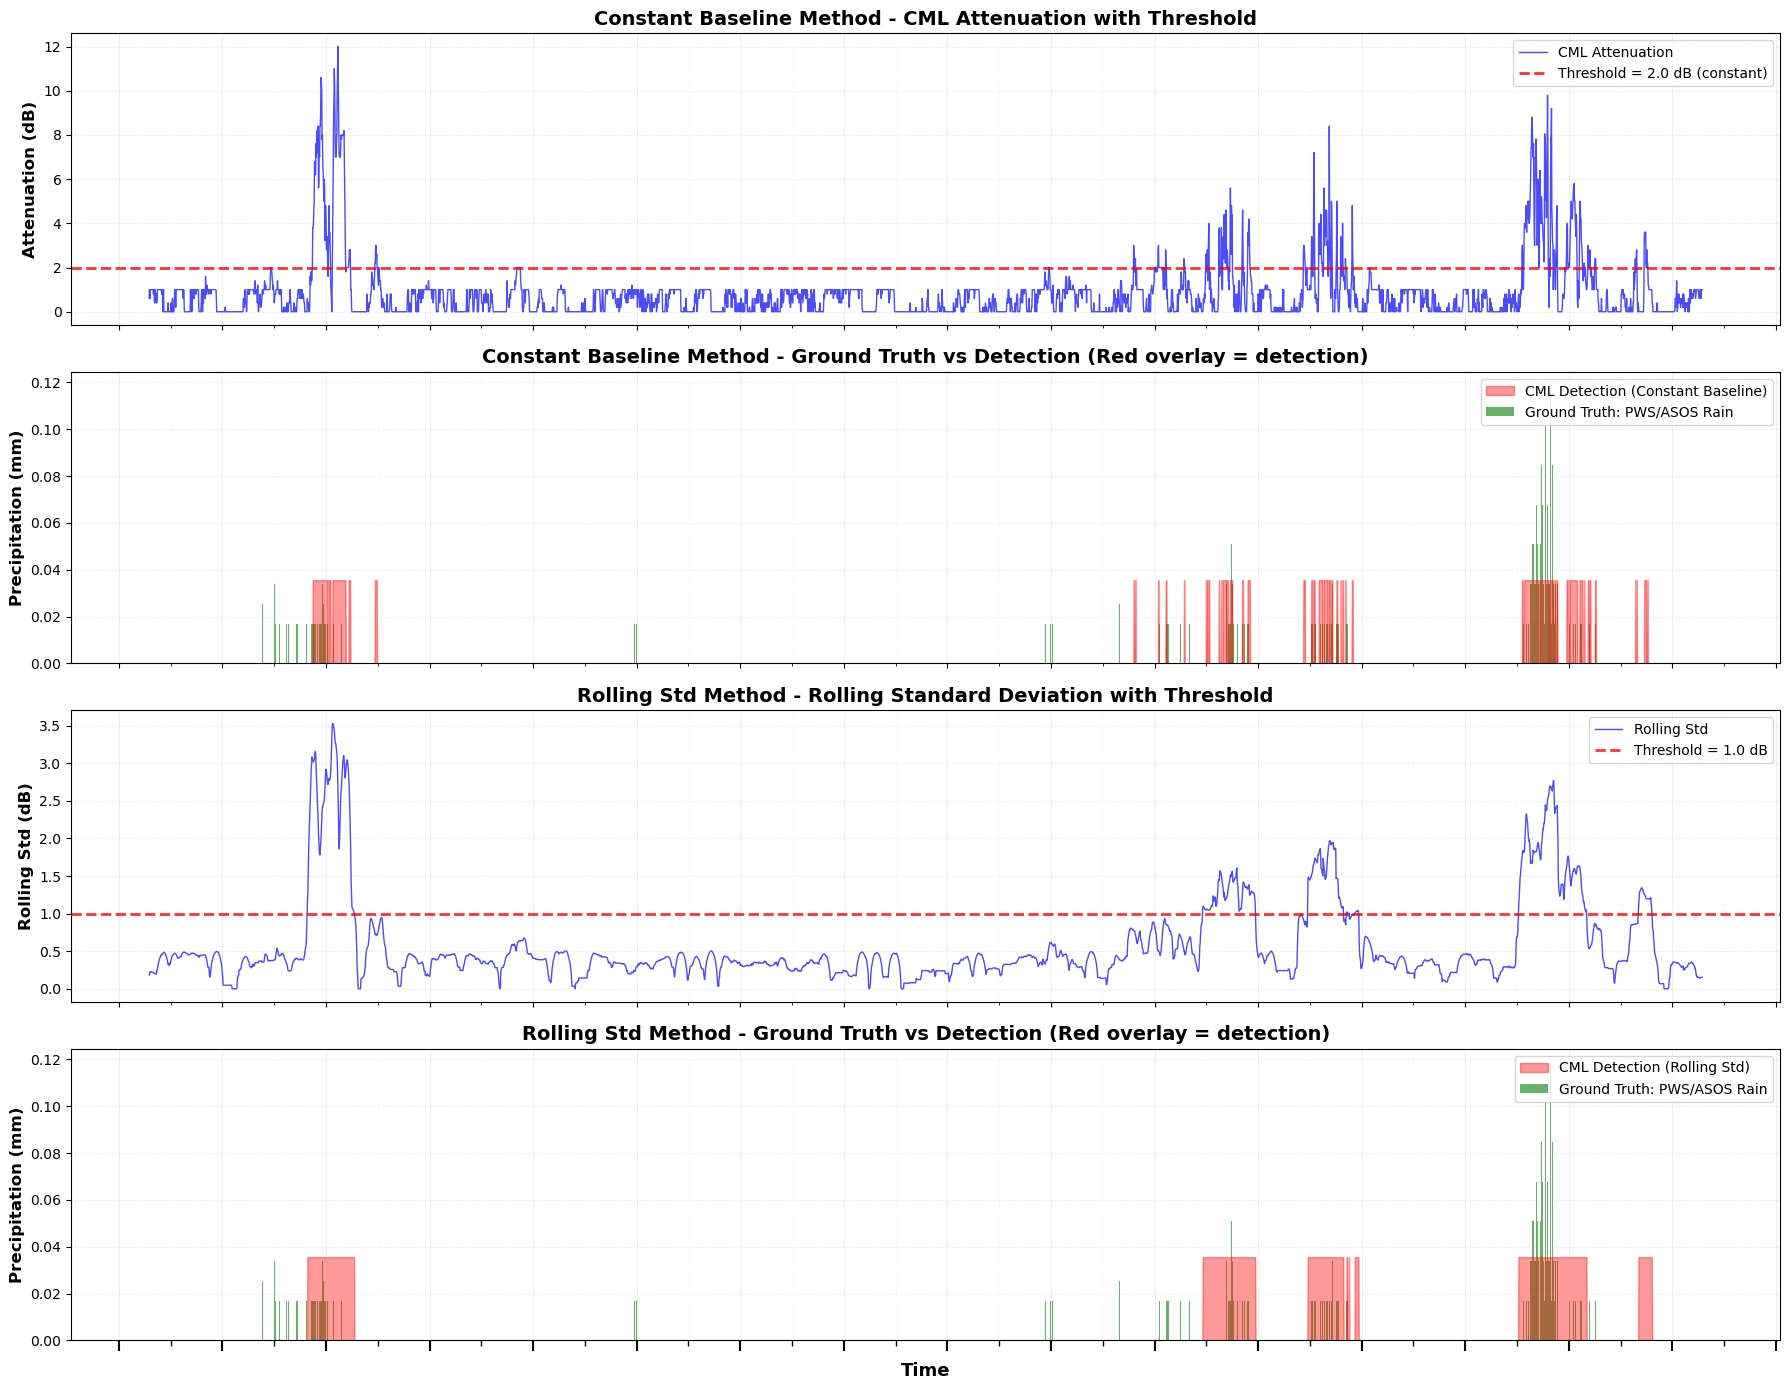

✓ Combined plots generated for both detection methods

COMPARISON EXPLANATION:
Green bars = Ground Truth Rain (PWS/ASOS stations)
  - PWS: Personal Weather Stations (5-min interval measurements)
  - ASOS: NOAA Automated Surface Observing System (hourly accumulation)
Red overlay = CML Detection (when attenuation > threshold)
  - Shows when CML link detects rain based on attenuation threshold

Detection Methods:
  Constant Baseline Method: Fixed threshold on attenuation (constant baseline)
  Rolling Std Method: Compare rolling standard deviation to threshold
  Both methods: Binary detection (1 = rain, 0 = no rain)


In [17]:
# Plot both detection methods side by side in one figure
# Shows Constant Baseline Method and Rolling Std Method for direct comparison

# Prepare ground truth rain data for comparison
df_rain_gt = None
if df_rain_combined is not None:
    df_rain_gt = df_rain_combined[['precip_mm']].copy()

# Option: Overlay detection on rain plot for better visualization
OVERLAY_DETECTION = True  # Change to False to see detection in separate panel

print("\n" + "=" * 70)
print("PLOTTING BOTH DETECTION METHODS")
print("=" * 70)

# Plot both methods in one figure
plot_both_detection_methods(
    df_cml=df_cml_aligned,
    df_const_detection=df_const_result,
    df_rolling_detection=df_rolling_result,
    df_rain_ground_truth=df_rain_gt,
    start_date=start_date if 'start_date' in locals() else None,
    end_date=end_date if 'end_date' in locals() else None,
    overlay_detection_on_rain=OVERLAY_DETECTION
)

print("\n" + "=" * 70)
print("COMPARISON EXPLANATION:")
print("=" * 70)
print("Green bars = Ground Truth Rain (PWS/ASOS stations)")
print("  - PWS: Personal Weather Stations (5-min interval measurements)")
print("  - ASOS: NOAA Automated Surface Observing System (hourly accumulation)")
print("Red overlay = CML Detection (when attenuation > threshold)")
print("  - Shows when CML link detects rain based on attenuation threshold")
print("\nDetection Methods:")
print("  Constant Baseline Method: Fixed threshold on attenuation (constant baseline)")
print("  Rolling Std Method: Compare rolling standard deviation to threshold")
print("  Both methods: Binary detection (1 = rain, 0 = no rain)")
